In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


# 신용카드 사기 거래 탐지
Credit Card Fraud Detection
- Time: 첫 거래 이후 경과 시간
- V1 ~ V28: PCA 처리된 익명 변수
- Amount: 거래 금액
- Class: 정상/사기 여부, 0=정상, 1=사기

*전체 284,807건 중 사기 거래 492건으로 매우 불균형한 데이터셋*

## 문제 1. creditcard.csv 파일을 읽어 df 변수에 저장하고, 상위 5개 행을 출력하시오.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 문제 2. 데이터의 행과 열 개수, 컬럼별 데이터 타입, 결측치 개수를 각각 확인하시오.

In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## 문제 3. Class 컬럼의 정상 거래와 사기 거래 개수를 확인하고, 비율도 함께 출력하시오.

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [8]:
pd.concat([df['Class'].value_counts(), df['Class'].value_counts(normalize=True)], axis=1)

,count,proportion
Class,,
0,284315,0.998273
1,492,0.001727


## 문제 4. Amount 컬럼의 평균, 표준편차, 최솟값, 최댓값 등 기본 통계량을 확인하시오.

In [9]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

## 문제 5. Class 값에 따라 Amount의 평균을 비교하시오.
- 정상 거래와 사기 거래의 평균 금액 비교

In [10]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

## 문제 6. Class 컬럼을 타겟 변수 y로 설정하고, 나머지 컬럼을 입력 변수 X로 설정하시오.

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

## 문제 7. 학습/평가 데이터 분리
- 학습 데이터와 평가 데이터를 8:2 비율로 분리하시오.
- 단, 사기 거래 비율이 유지되도록 stratify 옵션을 적용하시오.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## 문제 8. Amount와 Time 컬럼에 StandardScaler를 적용하시오.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler_list = ['Amount', 'Time']
X_train[scaler_list] = scaler.fit_transform(X_train[scaler_list])
X_test[scaler_list] = scaler.transform(X_test[scaler_list])

## 문제 9. RandomForestClassifier를 사용하여 사기 거래 탐지 모델을 학습하시오

In [14]:
df.shape

(284807, 31)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=30, # Kaggle에서 속도가 안나와서 30으로 설정
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=30, random_state=42)

## 문제 10. 학습한 모델을 사용하여 X_test에 대한 예측값을 y_pred 변수에 저장하시오.

In [16]:
y_pred = rf_model.predict(X_test)

## 문제 11. 정확도, Confusion Matrix, Classification Report를 출력하시오.

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f'Accuracy : {accuracy_score(y_test, y_pred)}')
print('confusion_matrix : ')
print(confusion_matrix(y_test, y_pred))
print('classification_report : ')
print(classification_report(y_test, y_pred))

Accuracy : 0.9995611109160493
confusion_matrix : 
[[56858     6]
 [   19    79]]
classification_report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## 문제 12. 사기 거래일 확률을 구한 뒤 ROC-AUC 점수를 출력하시오.

In [18]:
from sklearn.metrics import roc_auc_score

y_pred_prob = rf_model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred_prob)

np.float64(0.9667971666015872)

## 문제 13. 신경망 모델을 생성하시오.
입력층과 은닉층, 출력층을 구성하시오
- 은닉노드 `32개`, 활성함수 `relu`
- 은닉노드 `16개`, 활성함수 `relu`
- 출력층 이진분류, `sigmoid`사용

모델을 컴파일 하시오.
- `optimizer='adam'`, `loss='binary_crossentropy`, `accuracy`

모델을 학습하시오.
- `epochs=10`, `batch_size 32`

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# 모델 구성
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 컴파일
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

# 학습
history = model.fit(
        X_train, 
        y_train, 
        epochs=10,
        batch_size=32
)

2026-06-24 04:00:36.473914: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782273636.497546      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782273636.504208      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782273636.526042      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782273636.526073      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782273636.526076      58 computation_placer.cc:177] computation placer alr

Epoch 1/10


2026-06-24 04:00:39.446983: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9987 - loss: 0.0082
Epoch 2/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9994 - loss: 0.0030
Epoch 3/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9994 - loss: 0.0027
Epoch 4/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9994 - loss: 0.0025
Epoch 5/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9995 - loss: 0.0024
Epoch 6/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9995 - loss: 0.0023
Epoch 7/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9995 - loss: 0.0022
Epoch 8/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9995 - loss: 0.0021
Epoch 9/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9996 - loss: 0.0021
Epoch 10/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9995 - loss: 0.0021


## 문제 14. 학습된 모델을 이용하여 예측값을 생성하시오.
- 기준값 0.5

In [20]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
y_pred

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 913us/step


array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(56962, 1))

## 문제 15. 모델의 정확도를 출력하시오


In [21]:
from sklearn.metrics import accuracy_score, recall_score
print(f'accuracy_score : {accuracy_score(y_test, y_pred)}')
print(f'recall_score : {recall_score(y_test, y_pred)}')

accuracy_score : 0.999403110845827
recall_score : 0.8367346938775511


## 문제 16.딥러닝 모델 학습의 Loss 시각화하시오.

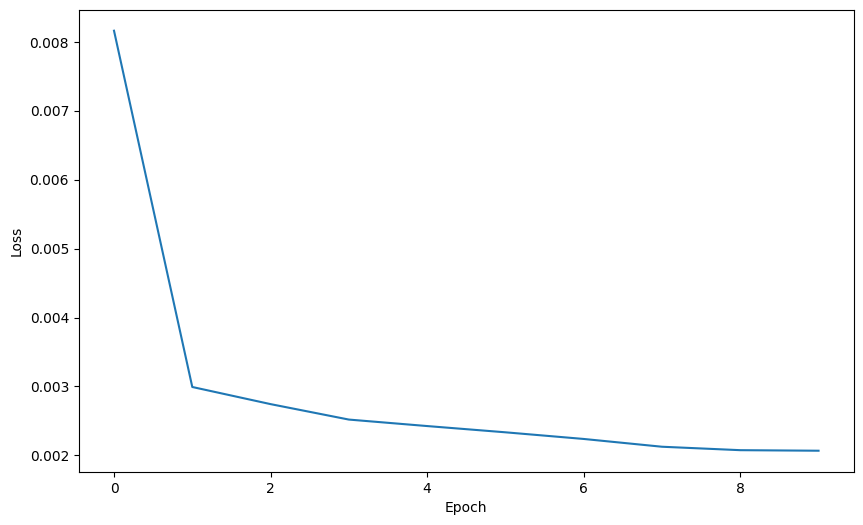

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 문제 17.딥러닝 모델의 Accuracy를 시각화하시오.

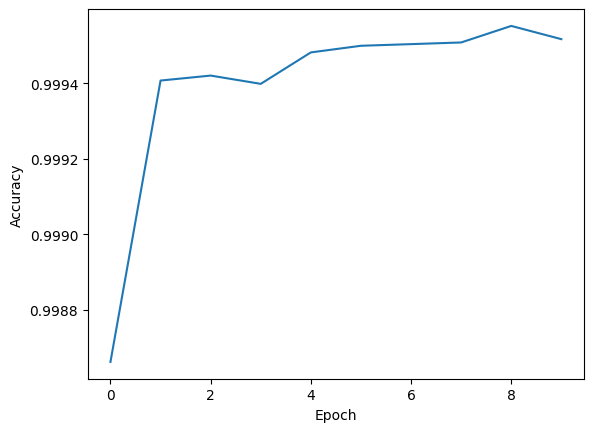

In [23]:
plt.plot(history.history['accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## 문제 18. ROC Curve를 시각화하시오.

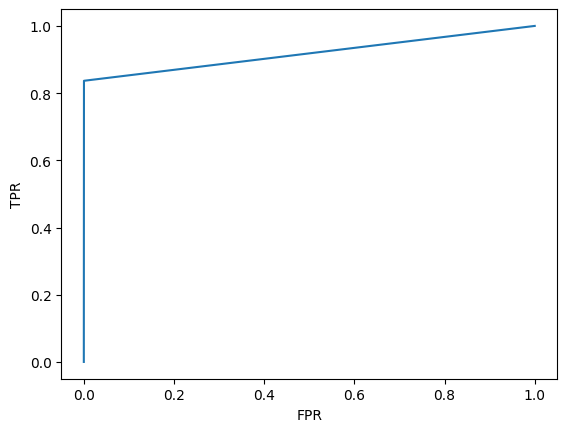

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()